In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm

def get_coeffs_orders(filename):
    """Obtain the linear coefficients of PES
       obtains associated orders, torsion argument for given coefficients
       filename is the name of the res file containing fit data"""
    
    params = []
    orders = []

    with open(filename, 'r') as file:
        #skip unnecessary lines 
        line = file.readline()
        while line[0].lower() != 'f':
            line = file.readline()
    
        line_split = line.split()
        while line_split[0][0].lower() == 'f':
            
            #get orders, convert to float 
            orders_line = line_split[1:-2]
            for j in range(len(orders_line)):
                orders_line[j] = float(orders_line[j])
            
            param = float(line_split[-1])
            
            #append into correct dipole component 
            params.append(param)
            orders.append(orders_line)
                
            line = file.readline()
            line_split = line.split()

    return (np.array(params), np.array(orders))

def get_non_linear_p(filename):
    """Obtain the non-linear coefficients of PES fit from 
       given residuals file, filename."""
    
    non_linear_params = []
    with open(filename, 'r') as file:
        #skip unnecessary lines 
        line = file.readline()
        while line[0] == '*':
            line = file.readline()
        
        line_split = line.split()
        #get nonlin_params 
        while len(line_split) == 3:
            non_lin_param = float(line_split[-1])
            non_linear_params.append(non_lin_param)

            line = file.readline()
            line_split = line.split()
    return np.array(non_linear_params)

In [2]:
def get_pes_v6(linear_params, nonlin_eq, orders):
    """computes the pes function for a given component direction,
       assumes fitting is done using the HPO2_v6 compiled fitting file.
       using input parameters (linear params, nonlin_eq) and powers
    """
    def pes(geometries):
        """Fitted pes function (R^6 -> R)
           - Assumes geometries is a n by 6 ndarray of input values, 
           - Assumes angles are given in degrees, (function converts to radians)
           Outputs value of potential energy for those given geometries.
        """
        pes_values = np.zeros(np.shape(geometries)[0])
        #set up variable arg to be modified to calculate pes values
        #start with input geometries
        arg = geometries.copy()
        nonlin_params = nonlin_eq.copy()
        
        #swap coord 1 and coord 2 (for v6 and 7 only)
        arg[:, 0:2] = arg[:, 0:2:-1]
        nonlin_params[0:2] = nonlin_params[[1, 0]]
        nonlin_params[-3:-1] = nonlin_params[[-2, -3]]
        
        #convert deg to rad, change angle poh
        arg[:, 3:] = arg[:, 3:] * np.pi/180
        nonlin_params[3:5] = nonlin_params[3:5]*np.pi/180
        
        #compute one sum-product term per loop
        for j in range(len(orders[:,0])):
            #initialise product parts
            term = np.zeros(np.shape(arg)[0])
            term.fill(linear_params[j])
            
            products = arg.copy()
            #compute morse_arguments
            products[:, :3] = (1 - np.exp(-1*nonlin_params[-3:]*
                                     (products[:, :3] - nonlin_eq[:3])
                                         ) 
                              )**orders[j,:3]
            
            #compute angle values
            products[:, 3] = (np.cos(products[:, 3]) 
                              - np.cos(nonlin_params[3])) **orders[j, 3]
            
            #this is flipped around
            products[:, 4] = ( np.cos(np.pi - nonlin_params[4]) - np.cos(np.pi - products[:, 4]) )**orders[j,4]

            #compute torsion
            products[:, 5] = np.cos(orders[j, 5]*products[:, 5])
            
            #compute term
            for k in range(6):
                term *= products[:,k]
                
            pes_values += term

        return pes_values  
    return pes

- 1D residual files are working, in the sense that the PES function correctly plots the 1D fitting functions.
- For whatever reason, the 6D functions however show weird behaviour, indication treatment of something not quite right.
- But implementations are the same as v4, so probably not the functional fit???

In [3]:
#check holes from the fit 6D_extend_0
p, orders = get_coeffs_orders('rpo2_test.res')
nonlin_p = get_non_linear_p('rpo2_test.res')
pes = get_pes_v6(p, nonlin_p, orders)
#pes = mpes.get_pes_v7_sin_sin(p, nonlin_p, orders)

#print(nonlin_p)
print(p)
print(nonlin_p)
print(orders)

[-7.8087840e-02  4.5734439e+04 -9.3651652e+03  3.2027542e+03
  2.4864558e+03  1.9534912e+03  1.6714402e+03  9.7629200e+02]
[  1.46781693   1.60347945   0.96798292 110.72852741 113.05478765
   2.63915684   1.66724612   1.91991687]
[[0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0.]
 [0. 3. 0. 0. 0. 0.]
 [0. 4. 0. 0. 0. 0.]
 [0. 5. 0. 0. 0. 0.]
 [0. 6. 0. 0. 0. 0.]
 [0. 7. 0. 0. 0. 0.]
 [0. 8. 0. 0. 0. 0.]]


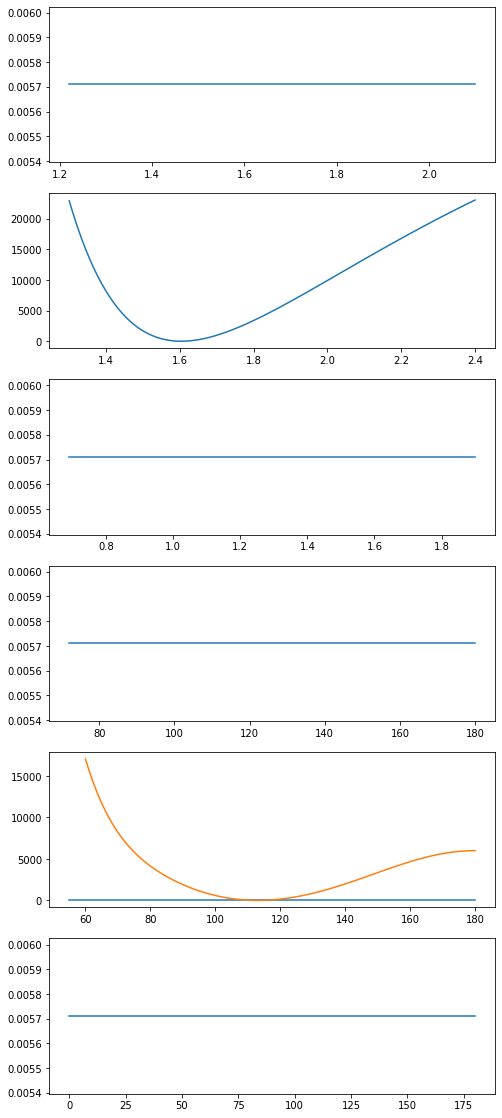

In [4]:
coordinate_lower_bounds = [1.22, 1.3, 0.69, 72, 55, 0]
coordinate_upper_bounds = [2.10, 2.4, 1.9, 180, 180, 180]
equilibriums = [1.468331, 1.604292, 0.967982, 110.7285, 113.0548, 0]
y = np.linspace(60, 180, 100)*np.pi/180
z = -1*(np.cos(np.pi - 113.04243964*np.pi/180) - np.cos(np.pi - y))

geometry1d = np.zeros((100, 6))
for j in range(5):
    #geometry1d[:, j] = nonlin_p[j]
    geometry1d[:, j] = equilibriums[j]

fig, ax = plt.subplots(6,1, figsize=(8,20))

for i in range(6):
    geometry_1d = geometry1d.copy()
    geometry_1d[:, i] = np.linspace(coordinate_lower_bounds[i],
                                    coordinate_upper_bounds[i],
                                    100)
    #print(pes(geometry_1d))
    ax[i].plot(geometry_1d[:, i], pes(geometry_1d))
ax[4].plot(y*180/np.pi,-0.46711763+18.058057*z+12693.899*z**2+1691.9903*z**3+3827.1852*z**4+4756.4832*z**5+362.28025*z**6-8188.4880*z**7+11494.131*z**8)
